In [1]:
import pandas as pd

df = pd.read_parquet("sba_7a_validated.parquet")
print(df.shape)
print(df.dtypes)

(428361, 31)
LocationID                           float64
BorrState                             object
BankName                              object
BankFDICNumber                       float64
BankNCUANumber                       float64
BankStreet                            object
BankCity                              object
BankState                             object
BankZip                               object
GrossApproval                        float64
SBAGuaranteedApproval                float64
ApprovalDate                  datetime64[ns]
ApprovalFY                             int64
FirstDisbursementDate         datetime64[ns]
ProcessingMethod                      object
InitialInterestRate                  float64
FixedorVariableInterestInd            object
TermInMonths                         float64
NaicsCode                             object
FranchiseCode                         object
ProjectCounty                         object
ProjectState                          obje

In [2]:
# Cheking the Skew of GrossApproval.
print("Skewness of GrossApproval Column is: ")
print(df["GrossApproval"].skew())

# The column is right skewed

Skewness of GrossApproval Column is: 
3.8122231117197116


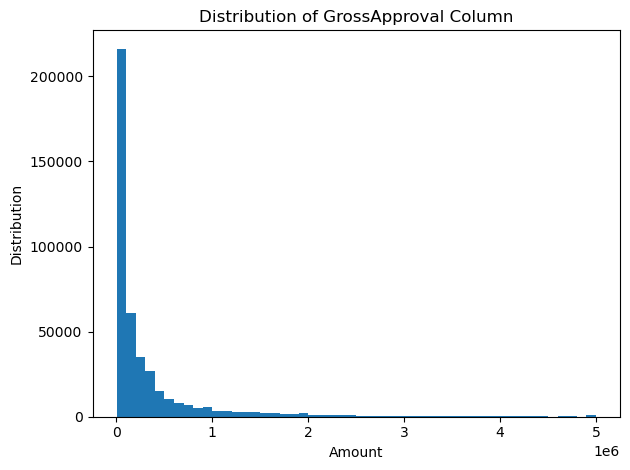

In [3]:
# Plotting Histogram with raw values of GrossApproval Column.
import matplotlib.pyplot as plt

plt.hist(df["GrossApproval"], bins=50)
plt.title("Distribution of GrossApproval Column")
plt.xlabel("Amount")
plt.ylabel("Distribution")
plt.tight_layout()
plt.savefig("gross_approval_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Changing the GrossApproval values in log due to high right skewness.
import numpy as np
df["log_GrossApproval"] = np.log1p(df["GrossApproval"])
print(df[["log_GrossApproval","GrossApproval"]])

        log_GrossApproval  GrossApproval
0               12.570719       288000.0
1               13.997833      1200000.0
2               11.695255       120000.0
3               11.918397       150000.0
4               10.126671        25000.0
...                   ...            ...
428356          12.429220       250000.0
428357          11.512935       100000.0
428358          11.231901        75500.0
428359          14.578184      2144000.0
428360          11.512935       100000.0

[428361 rows x 2 columns]


In [5]:
#Cheking skewness on log_GrossApproval
print("Skewness of Log GrossApproval Column: ")
print(df["log_GrossApproval"].skew())

# We can see that the skewness is reduced from 3.81 to 0.16 after transforming GrossApproval into log values.

Skewness of Log GrossApproval Column: 
0.16771009569246573


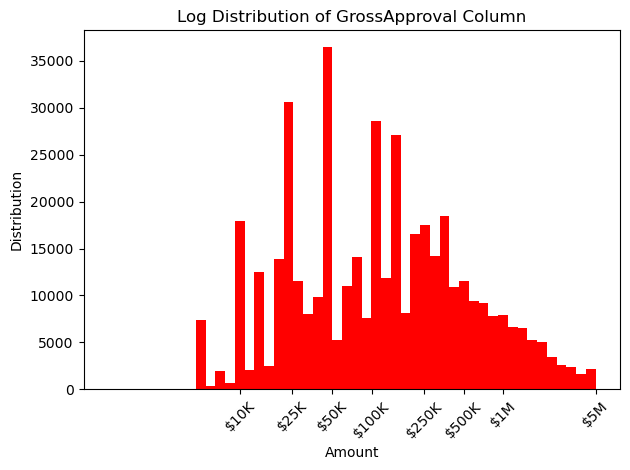

In [6]:
# Plotting Histogram with log values of log_GrossApproval Column.

plt.hist(df["log_GrossApproval"], bins=50,color="red")
ticks = [10000, 25000, 50000, 100000, 250000, 500000, 1000000, 5000000]
labels = ["$10K", "$25K", "$50K", "$100K", "$250K", "$500K", "$1M", "$5M"]
plt.xticks(np.log1p(ticks), labels, rotation=45)
plt.title("Log Distribution of GrossApproval Column")
plt.xlabel("Amount")
plt.ylabel("Distribution")
plt.tight_layout()
plt.savefig("log_approval_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# GrossApproval Column Fininds : 
# 1. The loan amount is heavily right skewed with a skewness of 3.81. The median loan is $125,000 and mean is $377,101.
# 2. Half of the loans are under $100,000. Smallest loan is $1000 and largest loan is $5,000,000. maximum allowed under the 7(a) program.
# 3. Applied log transforms to GrossApproval Skewness reduced to 0.17.
# 4. The log historgram chart shows which the raw values histogram did not show. Which is the loans pile up around numbers like
#    $25,000, $50,000, $100,000 and $150,000, with far fewer loans are present in between. Above roughly $500,000 
#    this pattern fades and the distribution becomes smooth, which suggests larger loans are sized to the actual 
#    cost of the project rather than picked as a round figure.

In [8]:
# Cheking numeric columns at a time.
num_cols = ["TermInMonths", "InitialInterestRate", "SBAGuaranteedApproval", "JobsSupported"]
for col in num_cols:
    print(col, "skew:", df[col].skew())
print()
print(df[num_cols].describe())

print("\nChecking Loans with 0 interest: ")
print(df[df["InitialInterestRate"] == 0]["LoanStatus"].value_counts())

# Insights - 
# 1. TermInMonths is slightly right skewed at 1.54. Median is 84 months. 25% of loans are under 74 months. Range is from 1 to 420months
# 2. InitialInterestRate is close to symmetric at 0.86. Median is 6%. most of the loans are between 5.5% and 7.5% interest. 
#    5 loans record 0% interest.
# 3. SBAGuaranteedApproval has skew of 3.82, which is almost same as GrossApproval skew. The is because SBAGuaranteedApproval is a fixed
#    percentage amount of GrossApproval.
# 4. JobsSupported is severely right skewed at 8.82. Median is 4 jobs, mean is 10.6, maximum is 2,150. 
#    Most loans support very few jobs while a small number support hundreds. (as per SBA these jobs are self reported by lender and are not validated.)

TermInMonths skew: 1.5412841786090445
InitialInterestRate skew: 0.8624916254886834
SBAGuaranteedApproval skew: 3.8211971856407483
JobsSupported skew: 8.8172574346026

        TermInMonths  InitialInterestRate  SBAGuaranteedApproval  \
count  428361.000000        428361.000000           4.283610e+05   
mean      113.475314             6.537044           2.540452e+05   
std        74.888861             1.567787           4.924071e+05   
min         1.000000             0.000000           5.000000e+02   
25%        74.000000             5.500000           2.000000e+04   
50%        84.000000             6.000000           6.858000e+04   
75%       120.000000             7.450000           2.430000e+05   
max       420.000000            13.500000           4.500000e+06   

       JobsSupported  
count  428361.000000  
mean       10.610824  
std        20.570049  
min         0.000000  
25%         2.000000  
50%         4.000000  
75%        11.000000  
max      2150.000000  

Checking Loa

In [9]:
# Checking categorial columns.
cat_cols = ["BusinessAge", "BusinessType", "ProcessingMethod",
            "RevolverStatus", "CollateralInd", "FixedorVariableInterestInd"]
for col in cat_cols:
    print(df[col].value_counts(normalize=True) * 100, "\n")

# Insights -
# 1. BusinessAge has inconsistent categories with vague bands like "Existing or more than 2 years old" overlapping the specific ones, 
#    suggesting SBA changed their definitions over time.We can see 8.96% are unanswered which is a missing data recorded as category.
#    The largest group is established businesses of 5+ years at 40.75%
# 2. BusinessType is dominated by corporations contributing about 87.12%, second is individuals at 11.05% and partnerships at 1.83%.
# 3. ProcessingMethod - 80% is covered by SBA Express at 51.56% and Preferred Lenders at 28.40%. Remaining 15 categories are below 1% each.
# 4. RevolverStatus is 67% term loans and 33% revolving credit. CollateralInd is 71% secured and 29% unsecured. 
#    FixedorVariableInterestInd is 78% variable and 22% fixed. All three are reasonably balanced, so each carries usable variation.

BusinessAge
Existing, 5 or more years                 40.754978
Startup, Loan Funds will Open Business    14.832209
New, Less than 1 Year old                 10.042422
Unanswered                                 8.959634
Existing or more than 2 years old          7.834704
Less than 4 years old but at least 3       6.549406
Less than 3 years old but at least 2       5.517186
Less than 5 years old but at least 4       4.069879
Change of Ownership                        1.435133
New Business or 2 years or less            0.004448
Name: proportion, dtype: float64 

BusinessType
CORPORATION    87.122033
INDIVIDUAL     11.046962
PARTNERSHIP     1.831005
Name: proportion, dtype: float64 

ProcessingMethod
SBA Express Program                          51.561884
Preferred Lenders Program                    28.395676
7a General                                    7.516090
Small Loan Advantage Initiative               5.980937
Patriot Express Loans                         1.283964
Community Express 

In [10]:
# Cheking Percentage split of PIF and CHGOFF. of deifferent BusinessAge
print(df.groupby("BusinessAge")["LoanStatus"].value_counts(normalize=True).unstack()*100)

LoanStatus                                 CHGOFF      P I F
BusinessAge                                                 
Change of Ownership                      7.112561  92.887439
Existing or more than 2 years old        9.974600  90.025400
Existing, 5 or more years                6.244256  93.755744
Less than 3 years old but at least 2     9.123313  90.876687
Less than 4 years old but at least 3     7.806971  92.193029
Less than 5 years old but at least 4     8.525081  91.474919
New Business or 2 years or less         47.368421  52.631579
New, Less than 1 Year old                8.735284  91.264716
Startup, Loan Funds will Open Business   9.699466  90.300534
Unanswered                               8.136922  91.863078


In [11]:
# checking BusinessAge over years.
print(pd.crosstab(df["BusinessAge"], df["ApprovalFY"]))

ApprovalFY                               2010   2011   2012   2013   2014  \
BusinessAge                                                                 
Change of Ownership                         0      0      0      0      0   
Existing or more than 2 years old           3      1      3      3      2   
Existing, 5 or more years               16482  20459  19738  20369  22884   
Less than 3 years old but at least 2     2448   2594   2291   2277   2757   
Less than 4 years old but at least 3     6317   6488   1968   1917   2370   
Less than 5 years old but at least 4     1823   1910   1883   1789   1988   
New Business or 2 years or less             0      0      0      0      0   
New, Less than 1 Year old                3619   3818   3973   4068   4597   
Startup, Loan Funds will Open Business   4985   5411   5536   6007   6448   
Unanswered                               3562   3844   2291   2249   2695   

ApprovalFY                               2015   2016   2017   2018   2019  

In [12]:
# BusinessAge findings - 
# 1. The charge-off rates vary by business age. Established businesses of 5 or more years have the lowest rate at 6.24%.
#    Startups have higher rate at 9.70% and business under 3 years old is around 9.12%.The baseline rate is 7.93%
# 2. The categoty New Business or 2 years or less shows a 47% percent charge off rate, but the group contain only 19 loans out of 428,361
#    The sample is far too small to be meaningful and this rate should be ignored.
# 3. The most important finding is that the SBA changed the way it classifies business age partway from 2018.
#    After doing cross tabulating BusinessAge against approval year shows that the detailed age bands such as "Existing, 5 or more years", 
#    "Less than 3 years", "Less than 4 years", "Less than 5 years" and "New, less than 1 year" appear from 2010 to 2017, 
#    fall sharply in 2018 and are completely absent in 2019. At the same time, "Existing or more than 2 years old" 
#    barely appears before 2018 and then jumps to over 16,000 loans in both 2018 and 2019. 
#    "Change of Ownership" and "New Business or 2 years or less" only appear from 2018 onwards.
# 4. This explains why "Existing or more than 2 years old" shows the highest charge-off rate at 9.97%. 
#    It is not that these businesses are riskier. The category is made up almost entirely of loans approved in 2018 and 2019, 
#    which have had less time to be repaid, so a larger share of the resolved loans in that group are charge-offs.
# 5. Because of this change from 2018 we cannot use BusinessAge directly as a feature since the categories are not comparable across the full period. 
#    It will need mapping to a consistent scheme or handling by time period.

In [13]:
# Checking Categorial columns
cat_cols = ["ProcessingMethod", "BusinessType", "RevolverStatus",
            "CollateralInd", "FixedorVariableInterestInd"]

for col in cat_cols:
    rate = df.groupby(col)["LoanStatus"].value_counts(normalize=True).unstack() * 100
    count = df[col].value_counts()
    result = rate.join(count.rename("Count"))
    print(result.sort_values("CHGOFF", ascending=False), "\n")

# Categorical findings against charge-off - 
# 1. Loans without any collateral, the charge off is at 10.26% compared to 6.98% for secured loans. 
#    This probably means that bank is asking for security if they are less confident on borrower.
# 2. Loans with varibale interest rate have charge off at 8.68% compared to 5.23% for fixed interest rates.
# 3. Partnership business have the lowest charge off rate at 4.69%, individuals have at 8.34% and corporations at 7.95%.
# 4. Loans with Revolving credit lines has charge off slightly less than term loans, 7.46% against 8.17%. it is a Small difference.
# 5. The ProcessingMethod show the widest spread. Several targeted lending programmes have high rates on meaningful volume.
#    Community Express at 20.22% on 5,108 loans, Community Advantage Initiative at 16.91% on 4,093 loans, 
#    Patriot Express at 13.44% on 5,500 loans, and Small Loan Advantage at 10.00% on 25,620 loans. 
#    All are well above the 7.93% baseline. The two largest programmes sit close to baseline, 
#    SBA Express at 7.17% on 220,871 loans and Preferred Lenders at 7.84% on 121,636 loans.

                                              CHGOFF       P I F   Count
ProcessingMethod                                                        
Community Advantage International Trade    33.333333   66.666667       3
Community Express                          20.223179   79.776821    5108
Community Advantage Initiative             16.906914   83.093086    4093
Patriot Express Loans                      13.436364   86.563636    5500
Gulf Opportunity Pilot Loan Program        10.374833   89.625167    1494
Export Express                             10.042918   89.957082    1165
Small Loan Advantage Initiative            10.000000   90.000000   25620
Rural Loan Initiative                       8.917910   91.082090    2680
International Trade Loans                   8.653846   91.346154    1040
7a General                                  8.367499   91.632501   32196
Preferred Lenders Program                   7.844717   92.155283  121636
SBA Express Program                         7.16798

In [15]:
# Checking Numerical columns.
num_cols = ["GrossApproval","TermInMonths","InitialInterestRate","JobsSupported"]
for col in num_cols:
    band = pd.qcut(df[col], q=10,duplicates="drop")
    rate = df.groupby(band)["LoanStatus"].value_counts(normalize=True).unstack() * 100
    count = band.value_counts()
    result = rate.join(count.rename("Count"))
    print(col)
-    print(result, "\n")

C:\Users\harsh\AppData\Local\Temp\ipykernel_8828\1755346658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(band)["LoanStatus"].value_counts(normalize=True).unstack() * 100
C:\Users\harsh\AppData\Local\Temp\ipykernel_8828\1755346658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(band)["LoanStatus"].value_counts(normalize=True).unstack() * 100
C:\Users\harsh\AppData\Local\Temp\ipykernel_8828\1755346658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

GrossApproval
                          CHGOFF      P I F  Count
GrossApproval                                     
(999.999, 15000.0]     10.042416  89.957584  42908
(15000.0, 25000.0]      9.069867  90.930133  46660
(25000.0, 50000.0]      7.594534  92.405466  66087
(50000.0, 70000.0]      7.076716  92.923284  16307
(70000.0, 100000.0]     7.980911  92.019089  44005
(100000.0, 150000.0]   10.782666  89.217334  42253
(150000.0, 260000.0]    7.595360  92.404640  41894
(260000.0, 428000.0]    7.784010  92.215990  42613
(428000.0, 925200.0]    6.068041  93.931959  42798
(925200.0, 5000000.0]   4.925763  95.074237  42836 

TermInMonths
                   CHGOFF      P I F   Count
TermInMonths                                
(0.999, 54.0]   36.547070  63.452930   43563
(54.0, 60.0]     4.301431  95.698569   48356
(60.0, 84.0]     4.659252  95.340748  148350
(84.0, 105.0]   29.838134  70.161866   16804
(105.0, 120.0]   2.128606  97.871394   92173
(120.0, 298.0]   5.728535  94.271465   36292

C:\Users\harsh\AppData\Local\Temp\ipykernel_8828\1755346658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(band)["LoanStatus"].value_counts(normalize=True).unstack() * 100


In [17]:
# Crostabulating TermInMonths and GrossApproval.
term_band = pd.qcut(df["TermInMonths"],q=10,duplicates="drop")
amt_band = pd.qcut(df["GrossApproval"],q=10,duplicates="drop")
print(pd.crosstab(term_band,amt_band))

GrossApproval   (999.999, 15000.0]  (15000.0, 25000.0]  (25000.0, 50000.0]  \
TermInMonths                                                                 
(0.999, 54.0]                 6404                6853                9466   
(54.0, 60.0]                  4643                8457               14481   
(60.0, 84.0]                 23647               25208               33546   
(84.0, 105.0]                 1247                 966                1476   
(105.0, 120.0]                6740                4603                5976   
(120.0, 298.0]                 226                 572                1109   
(298.0, 420.0]                   1                   1                  33   

GrossApproval   (50000.0, 70000.0]  (70000.0, 100000.0]  (100000.0, 150000.0]  \
TermInMonths                                                                    
(0.999, 54.0]                 1862                 5282                  3731   
(54.0, 60.0]                  4284                 647

In [18]:
short = df[df["TermInMonths"] <= 54]
mid = df[(df["TermInMonths"] > 84) & (df["TermInMonths"] <= 105)]

for name, subset in [("Short term", short), ("84-105 months", mid)]:
    print(name)
    print(subset["ProcessingMethod"].value_counts().head(5))
    print(subset["CollateralInd"].value_counts(normalize=True) * 100, "\n")

Short term
ProcessingMethod
SBA Express Program                31343
Preferred Lenders Program           4076
Small Loan Advantage Initiative     1651
7a General                          1094
Working Capital CAPLine              890
Name: count, dtype: int64
CollateralInd
Y    68.310263
N    31.689737
Name: proportion, dtype: float64 

84-105 months
ProcessingMethod
Preferred Lenders Program          6401
SBA Express Program                4799
Small Loan Advantage Initiative    1924
7a General                         1729
Community Advantage Initiative      528
Name: count, dtype: int64
CollateralInd
Y    75.595096
N    24.404904
Name: proportion, dtype: float64 



In [19]:
term_band = pd.qcut(df["TermInMonths"], q=10, duplicates="drop")
print(pd.crosstab(term_band, df["ApprovalFY"]))

ApprovalFY       2010   2011   2012   2013   2014   2015   2016   2017   2018  \
TermInMonths                                                                    
(0.999, 54.0]    4758   5251   4463   4166   4678   5180   4943   4441   3553   
(54.0, 60.0]     4047   4812   4218   4450   5735   6024   5295   5067   4934   
(60.0, 84.0]    14187  16341  14057  13570  15947  20345  20769  18440   9883   
(84.0, 105.0]    1707   1856   1537   1547   1465   1712   1857   1961   1794   
(105.0, 120.0]   7584   7209   6184   6826   7670   9545   9487   8638  14823   
(120.0, 298.0]   4058   4888   3516   3843   3706   4073   3860   3404   2853   
(298.0, 420.0]   2912   4183   3722   4312   4617   5219   5170   5129   4353   

ApprovalFY       2019  
TermInMonths           
(0.999, 54.0]    2130  
(54.0, 60.0]     3774  
(60.0, 84.0]     4811  
(84.0, 105.0]    1368  
(105.0, 120.0]  14207  
(120.0, 298.0]   2091  
(298.0, 420.0]   3206  


In [20]:
sub = df[df["ApprovalFY"] == 2012]
band = pd.qcut(sub["TermInMonths"], q=10, duplicates="drop")
rate = sub.groupby(band)["LoanStatus"].value_counts(normalize=True).unstack() * 100
count = band.value_counts()
print(rate.join(count.rename("Count")))

                   CHGOFF      P I F  Count
TermInMonths                               
(0.999, 48.0]   29.634966  70.365034   4164
(48.0, 60.0]     7.239318  92.760682   4517
(60.0, 84.0]     2.795760  97.204240  14057
(84.0, 120.0]    3.341536  96.658464   7721
(120.0, 288.0]   5.723325  94.276675   3477
(288.0, 345.0]   0.186121  99.813879   3761


C:\Users\harsh\AppData\Local\Temp\ipykernel_8828\3861520991.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = sub.groupby(band)["LoanStatus"].value_counts(normalize=True).unstack() * 100


In [24]:
mid = df[(df["TermInMonths"] > 84) & (df["TermInMonths"] <= 105)]
rate = mid.groupby("ApprovalFY")["LoanStatus"].value_counts(normalize=True).unstack() * 100
count = mid["ApprovalFY"].value_counts()
print(rate.join(count.rename("Count")))

               CHGOFF      P I F  Count
ApprovalFY                             
2010        30.814294  69.185706   1707
2011        17.995690  82.004310   1856
2012        14.313598  85.686402   1537
2013        15.707822  84.292178   1547
2014        20.068259  79.931741   1465
2015        26.460280  73.539720   1712
2016        31.610124  68.389876   1857
2017        40.795512  59.204488   1961
2018        47.770346  52.229654   1794
2019        51.169591  48.830409   1368


In [ ]:
# Numeric findings against charge-off

# Loan amount. Small loans fail more often than large ones. Loans under $15,000 charge off at 10.04% while loans above $925,000 charge off at 4.93%, 
# against a baseline of 7.93%. The general trend is that risk falls as loan size rises.

# One band breaks this pattern. Loans between $100,000 and $150,000 charge off at 10.78%, 
# much higher than the bands either side which sit around 7.6%. This is an isolated spike rather than part of a trend. 
# It may relate to the SBA guarantee changing from 85% to 75% at exactly $150,000, but this has not been confirmed.

# Loan term. This is the strongest relationship in the data. Loans with terms under 54 months charge off at 36.55%, 
# while loans with terms between 298 and 420 months charge off at only 0.05%.

# To check whether this was caused by timing, the same comparison was run on loans approved in 2012 alone, 
# which have had enough time to fully resolve. The pattern held, with 29.63% for the shortest terms and 0.19% for the longest. 
# So this is about the type of loan rather than how recent it is.

# Cross-tabulating term against loan amount shows why. Long term loans are almost all large loans, 
# which are typically backed by property. If the borrower fails, the lender can recover money by selling the asset. 
# Short term loans are small working capital loans with little to recover. So the loan term is really telling us what kind of loan it is.

# The 84 to 105 month band. This band charges off at 29.84% overall, even though the bands either side sit at 4.66% and 2.13%. 
# Breaking it down by approval year explains it. The rate is 30.81% in 2010, falls to 14.31% in 2012, then rises every year to 51.17% in 2019.

# Loans in this band run for 7 to 9 years. A loan approved in 2019 does not mature until around 2027, 
# so it cannot be marked paid in full yet and remains withheld under FOIA Exemption 4. But if that loan failed, 
# it usually failed early and is already recorded. So for recent years this band contains mostly failures and very few successes. 
# The higher rate in 2010 and 2011 is likely genuine, since those loans were approved just after the financial crisis.

# This matters beyond one band. It shows that recent approval years across the whole dataset are distorted in the same way, 
# and this must be taken into account when the data is split for training and testing.

# Interest rate. This has the clearest steady relationship. Charge-off rises consistently as the rate rises, 
# from 3.26% for loans under 5% interest up to 12.87% for loans above 8.99%. This is expected, 
# since the interest rate partly reflects the bank's own judgement of how risky the borrower is. 
# A higher rate means the bank already saw more risk when approving the loan.

# Jobs supported. Very little variation. Rates sit between 6.56% and 8.83% across all bands, 
# with a slight fall for loans supporting more jobs. This column carries weak signal, 
# and SBA states the figures are self reported by lenders and not validated.

In [22]:
# Checking NaicsCode column.
df["naics_sector"] = df["NaicsCode"].str[:2]
rate = df.groupby("naics_sector")["LoanStatus"].value_counts(normalize=True).unstack() * 100
count = df["naics_sector"].value_counts()
result = rate.join(count.rename("Count"))
print(result.sort_values("CHGOFF", ascending=False))

                 CHGOFF      P I F  Count
naics_sector                             
92            10.666667  89.333333     75
71            10.504886  89.495114  12280
45            10.239598  89.760402  16319
48             9.534197  90.465803  22005
42             9.088158  90.911842  23129
72             8.864119  91.135881  54636
61             8.621872  91.378128   5834
44             8.550680  91.449320  42137
23             8.534946  91.465054  46128
49             8.477842  91.522158   1557
81             8.185034  91.814966  37312
56             7.995233  92.004767  20137
51             7.763795  92.236205   5165
31             7.431977  92.568023   8894
21             7.170694  92.829306   1283
32             7.134880  92.865120   8059
54             7.005734  92.994266  43079
33             6.572090  93.427910  17270
22             6.250000  93.750000    352
53             5.625406  94.374594   9226
62             5.189334  94.810666  38926
11             4.825927  95.174073

In [25]:
# Checking ApprovalYear
rate = df.groupby("ApprovalFY")["LoanStatus"].value_counts(normalize=True).unstack() * 100
count = df["ApprovalFY"].value_counts()
print(rate.join(count.rename("Count")).sort_index())

# Approval Year FIndings

# We can see from 2010 to 2019 the charge off rate makes an U shape. 
# In 2010 the rate is 9.31%, it falls to 6.23% in 2013 and then raises in 10.09% in 2018 and slighly reducing in 2019 at 9.66%

# The high rate in 2010 and 2011 is due the effects of financial crisis. The loans were approved but the were still working through the economy.
# So the business that took loan during that period faced difficult conditions.

# The charge off rise after 2017 is not a real increase in risk. Recent loans that are performing well are still running and are
# withheld from the public file under FOIA Exemption 4, while loans that failed did so early and are already recorded.
# So recent years contain a higher share of failures only because the successes have not finished yet.
# This will need to be handled carefully when splitting the data for training and testing.

               CHGOFF      P I F  Count
ApprovalFY                             
2010         9.316485  90.683515  39253
2011         7.002694  92.997306  44540
2012         6.414304  93.585696  37697
2013         6.225138  93.774862  38714
2014         6.689032  93.310968  43818
2015         7.245960  92.754040  52098
2016         7.892022  92.107978  51381
2017         9.156754  90.843246  47080
2018        10.096461  89.903539  42193
2019         9.662203  90.337797  31587


In [26]:
# Checking the BorrState.

rate = df.groupby("BorrState")["LoanStatus"].value_counts(normalize=True).unstack() * 100
count = df["BorrState"].value_counts()
print(rate.join(count.rename("Count")).sort_values("CHGOFF", ascending=False).head(15))

              CHGOFF      P I F  Count
BorrState                             
MP         20.000000  80.000000      5
FL         12.319089  87.680911  20383
TX         10.503982  89.496018  32521
SC         10.392035  89.607965   3214
NJ         10.320285  89.679715  11240
LA         10.021387  89.978613   3273
IL          9.764723  90.235277  13856
VA          9.494451  90.505549   6488
AL          9.440212  90.559788   3019
VI          9.210526  90.789474     76
MO          9.201607  90.798393   7966
MD          9.133411  90.866589   5989
NV          9.113300  90.886700   3248
NY          9.098806  90.901194  27630
DC          9.062980  90.937020    651


In [39]:
df = df.drop(columns=["amount_band"])

In [40]:
df.to_parquet("sba_7a_eda.parquet", index=False)
df.to_csv("sba_7a_eda.csv", index=False)

In [ ]:
# Univariate findings

# Loan amounts range from $1,000 to $5,000,000, which is the programme maximum. The median is $125,000 and the mean is $377,101, 
# showing a strong right skew. Half of all loans are under $100,000. Amounts cluster heavily at round numbers 
# such as $25,000, $50,000 and $100,000, and this clustering fades above roughly $500,000.

# Loan terms have a median of 84 months. Interest rates are close to symmetric with a median of 6%, most falling between 5.5% and 7.45%. 
# Jobs supported is severely skewed, with a median of 4 and a maximum of 2,150, and SBA states this figure is self reported and unvalidated.

# Business type is dominated by corporations at 87%. Processing method is concentrated, with SBA Express at 52% and 
# Preferred Lenders at 28% covering 80% of loans, and more than 15 categories below 1% each. Around 71% of loans are secured with collateral, 
# 78% carry variable interest, and 67% are term loans rather than revolving credit.

# Bivariate findings

# The overall charge-off rate is 7.93%.

# Loan term shows the strongest relationship. Terms under 54 months charge off at 36.55% while terms of 298 to 420 months charge off at 0.05%. 
# Cross-tabulating term against loan amount shows long term loans are almost all large loans backed by property, 
# which the lender can recover against, while short term loans are small working capital facilities with little to recover.

# Interest rate shows the clearest steady trend, rising from 3.26% for loans under 5% to 12.87% for loans above 8.99%. 
# This partly reflects the bank's own risk judgement priced in at approval.

# Loan size runs the opposite way to intuition, with small loans failing more than large ones. Loans under $15,000 
# charge off at 10.04% against 4.93% for loans above $925,000.

# Industry matters. Arts and entertainment, retail, transportation and food services all sit above baseline, 
# while healthcare, finance, agriculture and real estate sit well below. The pattern reflects both demand stability 
# and whether the business holds recoverable assets.

# Unsecured loans charge off at 10.26% against 6.98% for secured. Variable rate loans charge off at 8.68% against 5.23% for fixed. 
# Established businesses of five or more years charge off at 6.24% against 9.70% for startups.

# Florida and Texas have the highest rates among large states at 12.32% and 10.50%. Testing whether this reflects industry mix showed it does not, 
# as their sector composition is similar to other large states.

# issues found

# SBA changed how it records business age partway through 2018, so the categories are not comparable across years 
# and must be made consistent before modelling.